# TP2/RR2 trading strategy results

Chapter 5 asks whether a detected TP2/RR2 violation can be converted into a
profitable portfolio. The strategy buys one side of the violated product
inequality and sells the other side. This gives an initial credit, but it is
not an arbitrage as the two option payoffs at settlement are still uncertain.

This notebook recreates:

1. the paper's reported results and the replication;
2. the six backtest specifications;
3. the paper-style same-day bid-ask robust test;
4. monthly factor regressions and
5. the 2023-2025 post-paper results.

## Running the notebook

This notebook uses the saved CSV files in `outputs/trading` to reproduce the Chapter 5 tables and figures. Running all cells does not rerun the trading backtests or factor regressions and does not modify the saved results. Instructions for rerunning the full trading analysis are provided in the README.

## 1. Setup

Open this notebook in VS Code or JupyterLab using the `.venv` Python kernel. Run it from the `notebooks/` folder so that:

- `OUT` points to the saved Chapter 5 results;
- `FIGURES` is where the figures are saved.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl


OUT = Path("../outputs/trading")
FIGURES = Path("../figures")
FIGURES.mkdir(exist_ok=True)

pl.Config.set_tbl_cols(20)

polars.config.Config

## 2. Load the saved results

- `reported` and `reported_year` contain the numbers transcribed from the
  paper and their annual series.
- `replication` compares our paper-style implementation with those series.
- `backtests` contains the six 2003-2022 specifications.
- `holdout` repeats them over 2023-2025, with 2025 ending on 29 August.
- `strong_signal` contains the paper-style same-day backtest using only violations that remain when purchases are priced at the ask and sales at the bid.
- `factors` contains the monthly regression estimates.

All return, Sharpe, drawdown and daily-loss calculations have already been
made by `src/trading.py`.

In [2]:
reported = pl.read_csv(OUT / "paper_reported_summary.csv")
reported_year = pl.read_csv(OUT / "paper_reported_by_year.csv")
replication = pl.read_csv(OUT / "paper_replication_summary.csv")

backtests = pl.read_csv(OUT / "backtest_2003_2022.csv")
holdout = pl.read_csv(OUT / "backtest_2023_2025.csv")

strong_signal = pl.read_csv(OUT / "strong_signal_same_day.csv")
factors = pl.read_csv(OUT / "factor_regressions.csv")

print("Saved trading result tables loaded.")


Saved trading result tables loaded.


## 3. Paper results and replication

The first table reports the four strategies considered by Glasserman, Li and Pirjol. The `T1`, `K1` and `K2` labels show which maturity and strikes are used in each strategy.

The paper reports the mean annual cash-balance return and the median of the annual Sharpe ratios. Each annual Sharpe uses that year's 12 monthly returns. The later backtest tables instead report one annualised Sharpe using all monthly returns in the sample:

$$
S = \sqrt{12}\frac{\bar{r}_m}{s(r_m)}.
$$

These two Sharpe measures are calculated differently and are not expected to match.

The replication covers 2003–2022, the years available in the cleaned sample. The return and Sharpe correlations measure how closely the replication follows the paper's year-by-year results.

In [3]:
paper_table = reported.select(
    "option_type",
    "denomination",
    "mean_annual_return_percent",
    "median_reported_sharpe",
)

display(paper_table)
display(replication)


option_type,denomination,mean_annual_return_percent,median_reported_sharpe
str,str,f64,f64
"""Calls""","""T1""",71.603478,2.97
"""Calls""","""K2""",67.174348,3.43
"""Puts""","""T1""",22.00913,3.56
"""Puts""","""K1""",37.691739,4.46


cp_flag,denomination,our_mean_return_percent,paper_mean_return_percent,return_correlation,sharpe_correlation
str,str,f64,f64,f64,f64
"""C""","""K2""",93.705946,76.6565,0.98458,0.951429
"""C""","""T1""",84.902586,81.7175,0.988826,0.961779
"""P""","""K1""",51.683373,42.1385,0.996804,0.990579
"""P""","""T1""",28.65469,25.2165,0.966026,0.975987


The next figure plots the annual series transcribed from the paper. These are
paper-style cash-balance returns, not marked portfolio-equity returns.


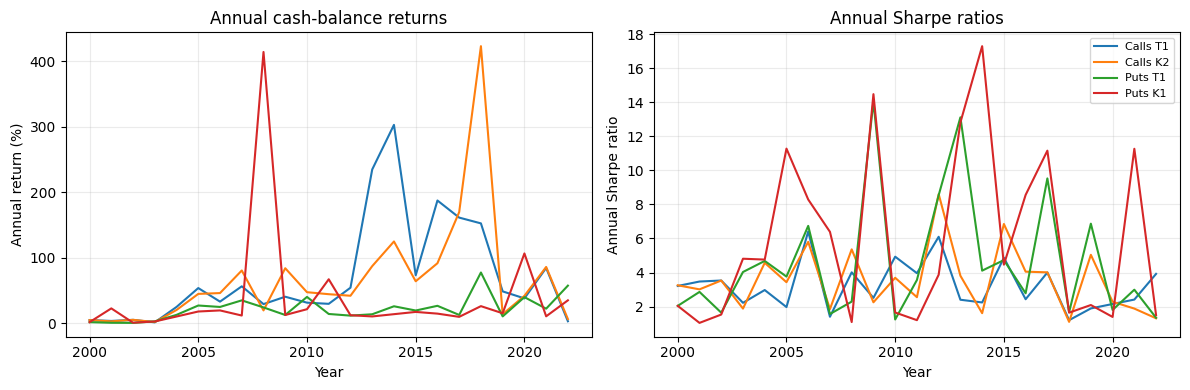

In [4]:
headline_strategies = [
    ("call_T1", "Calls T1"),
    ("call_K2", "Calls K2"),
    ("put_T1", "Puts T1"),
    ("put_K1", "Puts K1"),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for column_prefix, label in headline_strategies:
    axes[0].plot(
        reported_year["year"],
        reported_year[f"{column_prefix}_return"],
        label=label,
    )
    axes[1].plot(
        reported_year["year"],
        reported_year[f"{column_prefix}_sharpe"],
        label=label,
    )

axes[0].set(
    xlabel="Year",
    ylabel="Annual return (%)",
    title="Annual cash-balance returns",
)
axes[1].set(
    xlabel="Year",
    ylabel="Annual Sharpe ratio",
    title="Annual Sharpe ratios",
)

for ax in axes:
    ax.grid(alpha=0.25)

axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "paper_reported_performance.png", dpi=150)
plt.show()


## 4. Why cash is not portfolio equity

Selling an option raises cash immediately but creates an offsetting liability.
The small example below starts with wealth of 1.00, receives a 0.10 premium
and later settles at 0.12. Cash temporarily rises to 1.10, while marked equity
remains 1.00 because the open liability is included. Both finish at 0.98.

This is why the marked-equity specification can show larger interim losses
and possible margin pressure even when it uses exactly the same trades as the
paper cash specification.


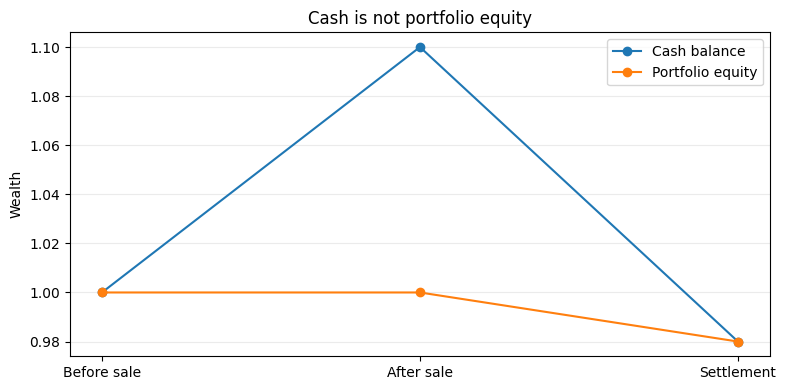

In [6]:
events = ["Before sale", "After sale", "Settlement"]
cash_balance = [1.00, 1.10, 0.98]
portfolio_equity = [1.00, 1.00, 0.98]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(events, cash_balance, marker="o", label="Cash balance")
ax.plot(events, portfolio_equity, marker="o", label="Portfolio equity")
ax.set(ylabel="Wealth", title="Cash is not portfolio equity")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
fig.savefig(FIGURES / "cash_is_not_equity.png", dpi=150)
plt.show()


## 5. Six backtest specifications, 2003-2022

The specifications are cumulative. Each row changes one main assumption from
the row above:

| Stage | Specification | What changes |
|---:|---|---|
| 1 | Paper baseline | Same-day mid-price trades; report cash-balance returns |
| 2 | Marked portfolio equity | Same trades, but include open positions at liquidation value |
| 3 | Same-day bid-ask | Buy at the offer and sell at the bid |
| 4 | Next-day bid-ask | Delay execution from signal date (t) to (t+1) |
| 5 | Mid-signal, liquid next-day | Add spread, lagged-volume, netting, whole-contract and commission rules |
| 6 | Bid-ask robust signal, liquid next-day | Require the signal itself to survive the date-(t) spread |

All stages use
cash-based sizing, initial wealth of USD 1 million and κ = 100. Stages 5 and 6 cap relative spread at 25%, require a lagged five-observation average
volume of at least 10 contracts, cap net participation at 10%, use whole
contracts and charge USD 1 per contract.

`mean_return` is the arithmetic mean of annual returns. `sharpe` is based on
all monthly returns in the sample. Maximum drawdown is the largest peak-to-
trough fall in marked or reported wealth and maximum daily loss is the worst
single-day percentage fall.


In [7]:
backtest_table = (
    backtests
    .with_columns(
        (100 * pl.col("mean_return")).round(2).alias("mean_return_percent"),
        pl.col("sharpe").round(2),
        (100 * pl.col("maximum_drawdown"))
        .round(2).alias("maximum_drawdown_percent"),
        (100 * pl.col("maximum_daily_loss"))
        .round(2).alias("maximum_daily_loss_percent"),
    )
    .select(
        "stage",
        "specification",
        "cp_flag",
        "denomination",
        "mean_return_percent",
        "sharpe",
        "maximum_drawdown_percent",
        "maximum_daily_loss_percent",
    )
)

display(backtest_table)


stage,specification,cp_flag,denomination,mean_return_percent,sharpe,maximum_drawdown_percent,maximum_daily_loss_percent
i64,str,str,str,f64,f64,f64,f64
1,"""Paper baseline""","""C""","""K2""",93.71,0.88,16.13,16.13
1,"""Paper baseline""","""C""","""T1""",84.9,1.49,1.23,1.23
1,"""Paper baseline""","""P""","""K1""",51.68,0.52,29.35,29.35
1,"""Paper baseline""","""P""","""T1""",28.65,1.62,6.03,6.03
2,"""Marked portfolio equity""","""C""","""K2""",93.58,0.81,47.43,29.25
…,…,…,…,…,…,…,…
5,"""Mid-signal, liquid next-day""","""P""","""T1""",-0.98,-0.05,132.72,451.2
6,"""Bid-ask robust signal, liquid …","""C""","""K2""",0.28,0.24,2.29,1.2
6,"""Bid-ask robust signal, liquid …","""C""","""T1""",0.4,0.5,1.62,1.36


## 6. Paper-style bid-ask robust signal

This table reproduces the paper's Section 5.4 test. It is separate from the six portfolio specifications above.

- **Signals:** bid-ask-robust violations found on the signal date.
- **Priced trades:** signals for which all required entry and settlement prices are available.
- **Hit rate:** percentage of priced trades that end with a profit.
- **Mean P&L/gross:** average final profit as a percentage of the initial gross option exposure.

Signals are identified and traded using the same closing quotes. Fractional positions are allowed and no capacity limit is imposed. Stage 6 uses delayed execution and adds liquidity restrictions.

In [9]:
strong_signal_table = strong_signal.with_columns(
    (100 * pl.col("mean_profit_on_gross"))
    .round(2).alias("mean_profit_percent"),
    (100 * pl.col("hit_rate"))
    .round(2).alias("hit_rate_percent"),
)

display(strong_signal_table)


cp_flag,signals,priced_trades,mean_profit_on_gross,hit_rate,mean_profit_percent,hit_rate_percent
str,i64,i64,f64,f64,f64,f64
"""C""",37287,37231,0.482324,0.999979,48.23,100.0
"""P""",571392,570727,0.066487,1.0,6.65,100.0


## 7. Factor regressions

The regressions are estimated using monthly returns from Stage 6. The dependent variable is portfolio (p)'s return in month (m).

- `SPX return` is the monthly S&P 500 return.
- `VIX` is the average monthly VIX level.
- `Log option volume` is aggregate monthly SPX option volume in logs.
- `Quoted spread` is the average relative bid-ask spread.

VIX, volume and spread are standardised, so their coefficients measure the
effect of a one standard deviation change. The standard errors are Newey-West
with three lags, which allows the monthly regression errors to have changing
variance and autocorrelation up to three months. `r_squared` is the fraction
of monthly return variation explained by the model.

The table below keeps the four headline strategies. Each coefficient is shown
with its Newey-West standard error and p-value.


In [11]:
headline_factors = factors.filter(
    ((pl.col("cp_flag") == "C") & pl.col("denomination").is_in(["T1", "K2"]))
    | ((pl.col("cp_flag") == "P") & pl.col("denomination").is_in(["T1", "K1"]))
)

factor_table = headline_factors.with_columns(
    pl.col("coefficient").round(5),
    pl.col("newey_west_standard_error").round(5),
    pl.col("p_value").round(3),
    pl.col("r_squared").round(3),
).select(
    "cp_flag",
    "denomination",
    "model",
    "factor",
    "coefficient",
    "newey_west_standard_error",
    "p_value",
    "r_squared",
)

display(factor_table)


cp_flag,denomination,model,factor,coefficient,newey_west_standard_error,p_value,r_squared
str,str,str,str,f64,f64,f64,f64
"""C""","""K2""","""market""","""constant""",0.00013,0.00014,0.355,0.018
"""C""","""K2""","""market""","""spx_log_return""",0.0101,0.00596,0.09,0.018
"""C""","""K2""","""market_volatility_liquidity""","""constant""",0.00012,0.00014,0.378,0.022
"""C""","""K2""","""market_volatility_liquidity""","""spx_log_return""",0.0109,0.00592,0.065,0.022
"""C""","""K2""","""market_volatility_liquidity""","""vix_z""",0.00002,0.0002,0.94,0.022
…,…,…,…,…,…,…,…
"""P""","""T1""","""market_volatility_liquidity""","""constant""",0.00045,0.00011,0.0,0.12
"""P""","""T1""","""market_volatility_liquidity""","""spx_log_return""",0.00068,0.0027,0.801,0.12
"""P""","""T1""","""market_volatility_liquidity""","""vix_z""",-0.00008,0.00008,0.313,0.12


## 8. Post-paper period, 2023-2025

The final table repeats all six specifications after the paper's sample. The
2023 and 2024 years are complete while the 2025 option data end on 29 August.

Because this period contains only two complete calendar years, a high Sharpe
ratio can be driven by a small number of monthly observations or trading days.


In [13]:
holdout_table = (
    holdout
    .with_columns(
        (100 * pl.col("mean_return")).round(2).alias("mean_return_percent"),
        pl.col("sharpe").round(2),
        (100 * pl.col("maximum_drawdown"))
        .round(2).alias("maximum_drawdown_percent"),
        (100 * pl.col("maximum_daily_loss"))
        .round(2).alias("maximum_daily_loss_percent"),
    )
    .select(
        "stage",
        "specification",
        "cp_flag",
        "denomination",
        "mean_return_percent",
        "sharpe",
        "maximum_drawdown_percent",
        "maximum_daily_loss_percent",
    )
)

display(holdout_table)


stage,specification,cp_flag,denomination,mean_return_percent,sharpe,maximum_drawdown_percent,maximum_daily_loss_percent
i64,str,str,str,f64,f64,f64,f64
1,"""Paper baseline""","""C""","""K2""",47.29,1.93,77.2,77.2
1,"""Paper baseline""","""C""","""T1""",55.26,2.29,0.94,0.94
1,"""Paper baseline""","""P""","""K1""",48.67,1.02,0.51,0.51
1,"""Paper baseline""","""P""","""T1""",30.89,2.97,-0.0,-0.0
2,"""Marked portfolio equity""","""C""","""K2""",46.7,1.78,16.57,15.52
…,…,…,…,…,…,…,…
5,"""Mid-signal, liquid next-day""","""P""","""T1""",4.03,2.63,5.62,3.68
6,"""Bid-ask robust signal, liquid …","""C""","""K2""",-0.03,-0.53,0.18,0.09
6,"""Bid-ask robust signal, liquid …","""C""","""T1""",-0.09,-0.59,0.42,0.34
